# Multivariate Analysis and Predictive Modeling of Digital Health Readiness in India

### DS3005 – Computational Algorithms in Data Science

**Team Members: Lakshya Gupta, Sarthak Goel, Krissh Modi**

In [1]:
"""
================================================================================
  Multivariate Analysis and Predictive Modeling of Digital Health Readiness
  in India — DS3005 Computational Algorithms in Data Science
  Authors : Lakshya Gupta, Sarthak Goel, Krissh Modi
  Date    : April 2026
================================================================================

Pipeline
────────
  STEP 1  │ Data Loading & Preprocessing
  STEP 2  │ Feature Engineering — Digital Readiness Score (DRS)
  STEP 3  │ Full-Predictor PCA
  STEP 4  │ K-Means Clustering
  STEP 5  │ Logistic Regression
  STEP 6  │ Random Forest
  STEP 7  │ Gradient Boosting
  STEP 8  │ Model Validation & Comparison
  STEP 9  │ Visualizations
================================================================================
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "legend.fontsize": 10})

SEED = 42
np.random.seed(SEED)

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — DATA LOADING & PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 72)
print("STEP 1 — Data Loading & Preprocessing")
print("=" * 72)

# Dataset: Citizen Survey Dataset, India (Kalita et al., 2026)
# Source : https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/M1DFBO
DATA_PATH = "./dataverse_files/FINAL DATA-CITIZEN_SURVEY_ALL_DATA-FINAL_SKS_09.05.2025 (1)/FINAL DATA-CITIZEN_SURVEY_ALL_DATA-FINAL_SKS_09.05.2025.dta"
df_raw = pd.read_stata(DATA_PATH)

print(f"  Raw dataset shape : {df_raw.shape}")

# ── Robust mappers for Stata-labeled categorical columns ──────────────────────
def _clean_labels(series):
    return series.astype(str).str.strip().str.lower()

def map_binary_labels(series, positive_labels, negative_labels):
    """Map string-labeled categories to {1, 0, NaN}."""
    cleaned = _clean_labels(series)
    pos = {x.lower() for x in positive_labels}
    neg = {x.lower() for x in negative_labels}
    out = pd.Series(np.nan, index=series.index, dtype=float)
    out.loc[cleaned.isin(pos)] = 1.0
    out.loc[cleaned.isin(neg)] = 0.0
    return out

def map_ordinal_labels(series, mapping):
    """Map string-labeled categories to ordered numeric scores."""
    cleaned = _clean_labels(series)
    mapping = {k.lower(): float(v) for k, v in mapping.items()}
    return cleaned.map(mapping).astype(float)

def map_frequency_labels(series):
    """Map frequency categories to {0, 1, 2} to retain ordinal information."""
    mapping = {
        "very little": 0.0,
        "somewhat": 1.0,
        "great extent": 2.0
    }
    return map_ordinal_labels(series, mapping)

df = df_raw.copy()

# ── Encode TARGET ─────────────────────────────────────────────────────────────
TARGET_COL = "telemedicine_usage"
df[TARGET_COL] = map_frequency_labels(df["c17_f"])

# ── Encode predictors ─────────────────────────────────────────────────────────
# c16_g uses Yes(Spontaneous)/Yes(Prompted)/No/DNA coding
df["c16_g"] = map_binary_labels(
    df["c16_g"],
    positive_labels={"Yes(Spontaneous)", "Yes(Prompted)", "Yes"},
    negative_labels={"No"},
)

# c17_a..e use Great Extent/Somewhat/Very Little/DK/DNA coding
for col in ["c17_a", "c17_b", "c17_c", "c17_d", "c17_e"]:
    df[col] = map_frequency_labels(df[col])

# ── Encode gender (Female = 1, Male = 0) ─────────────────────────────────────
df["gender"] = map_binary_labels(
    df["a2c"],
    positive_labels={"Female"},
    negative_labels={"Male"},
)

# ── Encode residence (Rural = 1, Urban = 0) ──────────────────────────────────
df["rural"] = map_binary_labels(
    df["residence"],
    positive_labels={"Rural"},
    negative_labels={"Urban"},
)

# ── Encode c18_a (Yes = 1, No = 0) ────────────────────────────────────────────
df["c18_a"] = map_binary_labels(
    df["c18_a"],
    positive_labels={"Yes"},
    negative_labels={"No"},
)

# ── Encode education as ordinal integer ───────────────────────────────────────
EDU_ORDER = {
    "primary": 1,
    "middle": 2,
    "secondary": 3,
    "higher-secondary+": 4,
}
df["education"] = map_ordinal_labels(df["rec_a2d"], EDU_ORDER)

# ── Final predictor column names ──────────────────────────────────────────────
PREDICTOR_COLS = [
    "a2b_age",    # Age
    "a2g_food",   # Household food expenditure (income proxy)
    "education",  # Ordinal education level
    "gender",     # Female=1, Male=0
    "rural",      # Rural=1, Urban=0
    "c16_g",      # Internet as health info source (proxy)
    "c17_a",      # Uses internet for general health information
    "c17_b",      # Uses internet for e-pharmacies
    "c17_c",      # Uses internet to find doctors/facilities
    "c17_d",      # Uses internet for medical records
    "c17_e",      # Uses internet for treatment help
    "c18_a",      # Health card importance
]

# ── Subset and drop rows with missing target ──────────────────────────────────
df_work = df[PREDICTOR_COLS + [TARGET_COL]].copy()
df_work = df_work[df_work[TARGET_COL].notna()].reset_index(drop=True)

print(f"  Rows with valid target (c17_f): {len(df_work):,}")
print(f"  Target distribution:\n{df_work[TARGET_COL].value_counts().sort_index()}")

# ── Missing value imputation ──────────────────────────────────────────────────
continuous_vars = ["a2b_age", "a2g_food"]
ordinal_binary_vars = [c for c in PREDICTOR_COLS if c not in continuous_vars]

df_work[continuous_vars] = (SimpleImputer(strategy="median")
                            .fit_transform(df_work[continuous_vars]))
df_work[ordinal_binary_vars] = (SimpleImputer(strategy="most_frequent")
                                .fit_transform(df_work[ordinal_binary_vars]))

print(f"  Missing values after imputation: {df_work.isnull().sum().sum()}")

# ── Z-score standardisation — required before clustering ──────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_work[PREDICTOR_COLS])
df_scaled = pd.DataFrame(X_scaled, columns=PREDICTOR_COLS, index=df_work.index)

print(f"  Predictors standardised: {df_scaled.shape}\n")

y = df_work[TARGET_COL].values.astype(int)
N = len(df_work)
df = df_work

STEP 1 — Data Loading & Preprocessing
  Raw dataset shape : (50217, 232)
  Rows with valid target (c17_f): 30,629
  Target distribution:
telemedicine_usage
0.0    20044
1.0     5823
2.0     4762
Name: count, dtype: int64
  Missing values after imputation: 0
  Predictors standardised: (30629, 12)



In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — FEATURE ENGINEERING: Digital Readiness Score (DRS)
# ══════════════════════════════════════════════════════════════════════════════
# DRS conceptually captures the cumulative digital health behavior of an individual.
# Based on feedback, using PCA on categorical/binary variables was methodologically 
# flawed. Instead, we use an intuitive, theoretically sound additive scale. 
# DRS is the simple sum of the ordinal usage scores for health digital channels 
# (c17_a through c17_e, plus internet health source proxy c16_g).

print("=" * 72)
print("STEP 2 — Feature Engineering: Digital Readiness Score (DRS)")
print("=" * 72)

DRS_COLS = ["c16_g", "c17_a", "c17_b", "c17_c", "c17_d", "c17_e"]

# Max possible score: c16_g is 0/1, c17_a to e are 0/1/2. Max sum = 11.
df["DRS"] = df[DRS_COLS].sum(axis=1)

# Normalise to 0-1 range for model consistency
df["DRS_norm"] = df["DRS"] / df["DRS"].max()
df_scaled["DRS"] = df["DRS_norm"]

print(f"  DRS formulated as sum of {len(DRS_COLS)} features.")
print(f"  Max possible score: {df['DRS'].max()}")
print(f"  Mean = {df['DRS'].mean():.3f}, Std = {df['DRS'].std():.3f}")
print(f"  DRS_norm added to scaled features.\n")


STEP 2 — Feature Engineering: Digital Readiness Score (DRS)
  DRS formulated as sum of 6 features.
  Max possible score: 11.0
  Mean = 5.246, Std = 3.408
  DRS_norm added to scaled features.



In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — K-MEANS CLUSTERING
# ══════════════════════════════════════════════════════════════════════════════
# K-Means applied directly to the original standardised feature space.
# Minimises WCSS = Σ_k Σ_{i∈Ck} ‖xᵢ − μₖ‖²
# Optimal K selected jointly by the elbow method and maximum silhouette score.
# Silhouette is computed on a 5,000-point subsample for efficiency.

print("=" * 72)
print("STEP 3 — K-Means Clustering")
print("=" * 72)

Z = df_scaled[PREDICTOR_COLS].values # Using original standardised features 

K_RANGE = range(2, 8)
wcss, sil_scores = [], []

sil_idx  = np.random.choice(N, min(5000, N), replace=False)
Z_sample = Z[sil_idx]

print("  Evaluating K values...", end="")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10,
                max_iter=300, random_state=SEED)
    km.fit(Z)
    wcss.append(km.inertia_)
    labels_sample = km.labels_[sil_idx]
    sil = (silhouette_score(Z_sample, labels_sample, random_state=SEED)
           if len(np.unique(labels_sample)) > 1 else -1)
    sil_scores.append(sil)
    print(".", end="", flush=True)
print()

best_k_sil = K_RANGE.start + int(np.argmax(sil_scores))
print(f"\n  K   WCSS              Silhouette")
for k, w, s in zip(K_RANGE, wcss, sil_scores):
    marker = "  <- optimal" if k == best_k_sil else ""
    print(f"  K={k}  {w:>12,.0f}    {s:.4f}{marker}")

K_OPT          = best_k_sil
km_final       = KMeans(n_clusters=K_OPT, init="k-means++", n_init=20,
                        max_iter=500, random_state=SEED)
cluster_labels = km_final.fit_predict(Z)
df["cluster"]  = cluster_labels

print(f"\n  Optimal K = {K_OPT}")
for k, cnt in zip(*np.unique(cluster_labels, return_counts=True)):
    print(f"  Cluster {k}: {cnt:,}  ({cnt/N*100:.1f}%)")

cluster_profile = (df[PREDICTOR_COLS + [TARGET_COL, "cluster"]]
                   .groupby("cluster").mean().round(3))
print(f"\n  Cluster Profiles:\n{cluster_profile}\n")


STEP 3 — K-Means Clustering
  Evaluating K values.........

  K   WCSS              Silhouette
  K=2       291,273    0.1913
  K=3       263,919    0.2056  <- optimal
  K=4       241,981    0.1626
  K=5       224,750    0.1523
  K=6       213,339    0.1524
  K=7       205,659    0.1376

  Optimal K = 3
  Cluster 0: 12,601  (41.1%)
  Cluster 1: 15,811  (51.6%)
  Cluster 2: 2,217  (7.2%)

  Cluster Profiles:
         a2b_age  a2g_food  education  gender  rural  c16_g  c17_a  c17_b  \
cluster                                                                     
0         39.740  5988.046      2.142   0.486  0.758  0.459  0.599  0.218   
1         35.842  6069.533      2.993   0.380  0.640  0.893  1.668  1.441   
2         37.444  6294.406      2.518   0.424  0.661  0.615  1.108  0.709   

         c17_c  c17_d  c17_e  c18_a  telemedicine_usage  
cluster                                                  
0        0.392  0.255  0.136    1.0               0.153  
1        1.577  1.505  0.802  

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — LOGISTIC REGRESSION (Multinomial)
# ══════════════════════════════════════════════════════════════════════════════
# Due to feedback about loss of information, we model the 3-level target 
# directly using multinomial logistic regression instead of collapsing to binary.
# P(Y=k | X) = exp(β_kᵀX) / Σ_j exp(β_jᵀX)

print("=" * 72)
print("STEP 4 — Logistic Regression (Multinomial)")
print("=" * 72)

df_model = df_scaled.copy()

# Interaction: Gender × Rural (both raw binary from original encoding)
df_model["gender_x_rural"]    = df["gender"]  * df["rural"]

# Interaction: Income × Internet (standardised food expenditure × binary c16_g)
df_model["income_x_internet"] = df_scaled["a2g_food"] * df["c16_g"]

cluster_dummies = pd.get_dummies(df["cluster"], prefix="cluster", drop_first=True)
df_model = pd.concat([df_model.reset_index(drop=True),
                      cluster_dummies.reset_index(drop=True)], axis=1)

FEATURE_COLS = (
    PREDICTOR_COLS
    + ["DRS", "gender_x_rural", "income_x_internet"]
    + list(cluster_dummies.columns)
)

X = df_model[FEATURE_COLS].values
print(f"  Feature matrix: {X.shape}  (p = {X.shape[1]})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"  Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

# Note: classes are 0, 1, 2
lr = LogisticRegression(C=1.0, multi_class='multinomial', solver="lbfgs", max_iter=500,
                        class_weight="balanced", random_state=SEED)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)  # (N, 3)

# For interpretability: Odds Ratios for class 2 (Great Extent) vs. class 0 (Very Little) Base
coef_class2 = lr.coef_[-1] # if classes are 0,1,2, then to get class 2 effect...
odds_ratios = np.exp(coef_class2)
print("  Odds Ratios for active users (sorted by effect magnitude):")
for feat, OR in sorted(zip(FEATURE_COLS, odds_ratios), key=lambda x: -abs(x[1] - 1)):
    print(f"    {feat:<30}: {OR:.4f}  {'↑' if OR > 1 else '↓'}")
print()


STEP 4 — Logistic Regression (Multinomial)
  Feature matrix: (30629, 17)  (p = 17)
  Train: 24,503  |  Test: 6,126
  Odds Ratios for active users (sorted by effect magnitude):
    c17_e                         : 2.5228  ↑
    c17_b                         : 1.5433  ↑
    cluster_1                     : 0.6072  ↓
    c17_d                         : 1.2986  ↑
    education                     : 1.2925  ↑
    c17_c                         : 1.2347  ↑
    c17_a                         : 1.1956  ↑
    c16_g                         : 1.1608  ↑
    c18_a                         : 1.1345  ↑
    rural                         : 1.0941  ↑
    a2g_food                      : 1.0892  ↑
    gender_x_rural                : 0.9154  ↓
    cluster_2                     : 0.9397  ↓
    a2b_age                       : 0.9511  ↓
    DRS                           : 0.9599  ↓
    gender                        : 1.0276  ↑
    income_x_internet             : 1.0225  ↑



In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════
# Ŷ = mode(T_1(X), …, T_B(X))
# Multiclass classification support using Gini impurity.

print("=" * 72)
print("STEP 5 — Random Forest")
print("=" * 72)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, max_features="sqrt",
    class_weight="balanced", oob_score=True,
    n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)  # (N, 3)

print(f"  OOB accuracy: {rf.oob_score_:.4f}")

importance_df = (pd.DataFrame({"feature": FEATURE_COLS,
                                "importance": rf.feature_importances_})
                 .sort_values("importance", ascending=False))
print("\n  Top-10 Feature Importances:")
print(importance_df.head(10).to_string(index=False))
print()


STEP 5 — Random Forest
  OOB accuracy: 0.8066

  Top-10 Feature Importances:
          feature  importance
            c17_e    0.375357
              DRS    0.198309
            c17_d    0.105423
        education    0.068778
            c17_b    0.054035
            c17_c    0.053456
        cluster_1    0.039700
            c17_a    0.024883
income_x_internet    0.019785
         a2g_food    0.018530



In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — GRADIENT BOOSTING
# ══════════════════════════════════════════════════════════════════════════════
# Third comparator. Trees are built sequentially, each correcting residuals.
# Subsample=0.8 adds stochasticity.

print("=" * 72)
print("STEP 6 — Gradient Boosting")
print("=" * 72)

gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, subsample=0.8, random_state=SEED
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)  # (N, 3)

print("  Gradient Boosting fitted.\n")


STEP 6 — Gradient Boosting
  Gradient Boosting fitted.



In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — MODEL VALIDATION & COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
# Multiclass validation using macro and weighted metrics.

print("=" * 72)
print("STEP 7 — Model Validation & Comparison")
print("=" * 72)


def compute_metrics(y_true, y_pred, y_prob, name):
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Recall"   : round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "F1 (Wt)"  : round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_prob, multi_class="ovo"), 4),
    }


results_df = pd.DataFrame([
    compute_metrics(y_test, y_pred_lr, y_prob_lr, "Logistic Regression"),
    compute_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest"),
    compute_metrics(y_test, y_pred_gb, y_prob_gb, "Gradient Boosting"),
]).set_index("Model")

print("\n  Holdout Test Set Metrics:")
print(results_df.to_string())

# Cross-validation for multi-class uses multi_class='ovo' in AUC scoring if supported, 
# but simply evaluating accuracy/F1 is safer in common cross_val_score strings.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("\n  5-Fold CV Weighted F1 (training set):")
for model, name in [(lr, "Logistic Regression"),
                    (rf, "Random Forest"),
                    (gb, "Gradient Boosting")]:
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring="f1_weighted", n_jobs=-1)
    print(f"    {name:<25}: {scores.mean():.4f} ± {scores.std():.4f}"
          f"  (folds: {np.round(scores, 3)})")


STEP 7 — Model Validation & Comparison

  Holdout Test Set Metrics:
                     Accuracy  Precision  Recall  F1 (Wt)  ROC-AUC
Model                                                             
Logistic Regression    0.7922     0.7956  0.7922   0.7936   0.8551
Random Forest          0.8046     0.8158  0.8046   0.8089   0.8973
Gradient Boosting      0.8284     0.8213  0.8284   0.8234   0.8943

  5-Fold CV Weighted F1 (training set):
    Logistic Regression      : 0.7969 ± 0.0039  (folds: [0.801 0.792 0.792 0.799 0.8  ])
    Random Forest            : 0.8123 ± 0.0031  (folds: [0.812 0.818 0.809 0.813 0.811])
    Gradient Boosting        : 0.8191 ± 0.0047  (folds: [0.826 0.812 0.822 0.819 0.817])


STEP 8 — Generating Visualizations


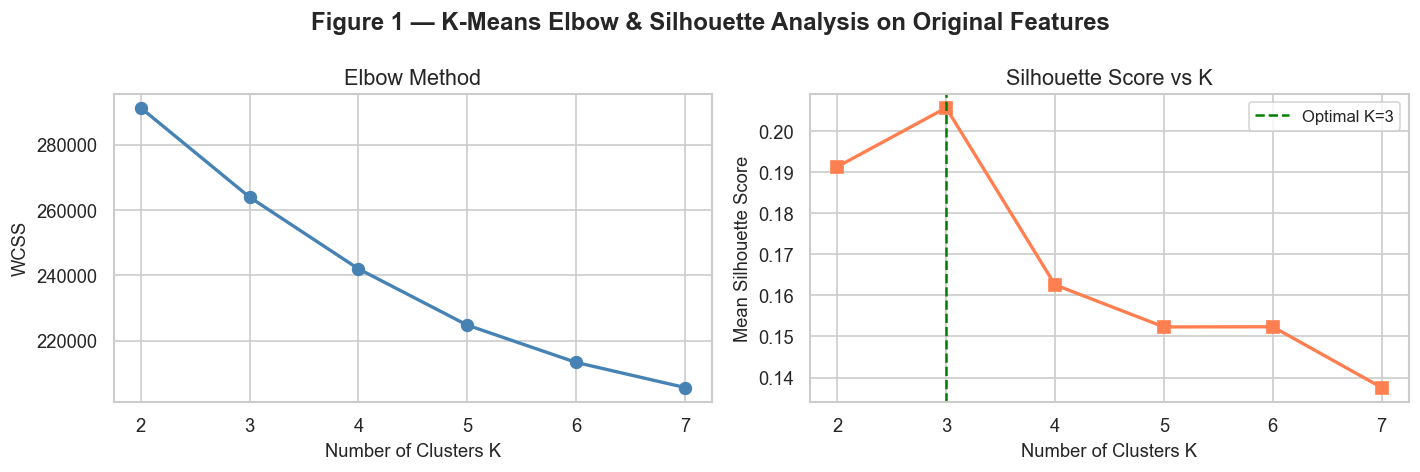

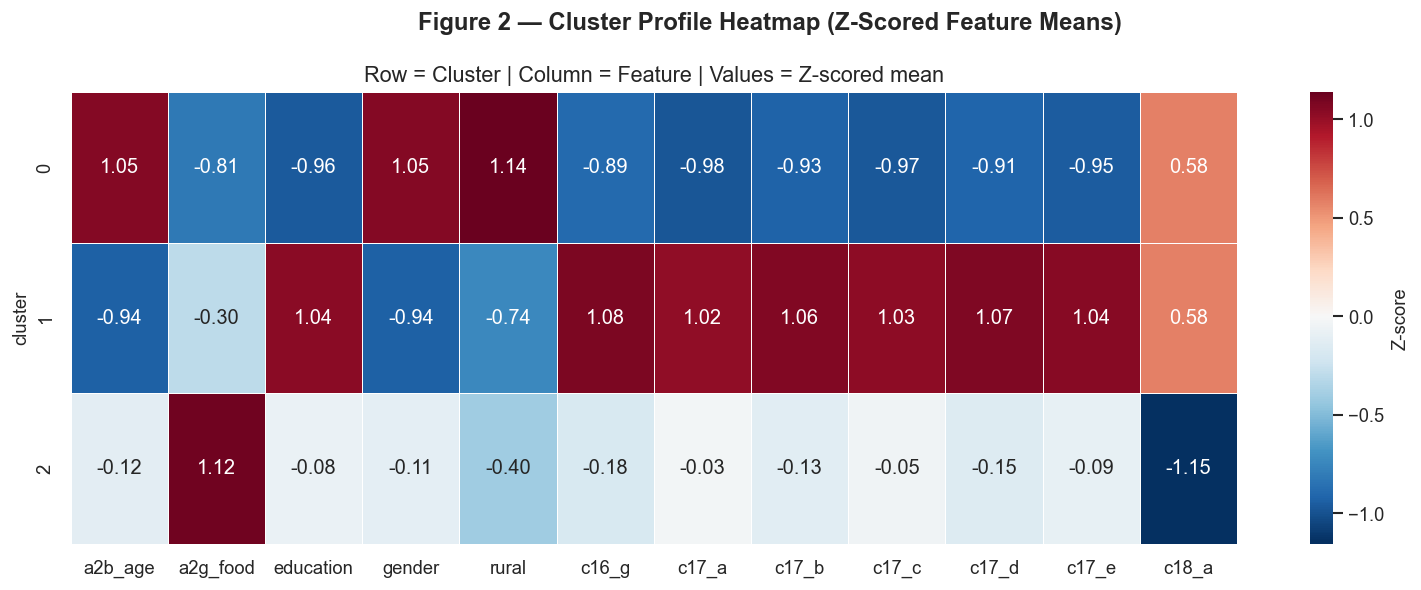

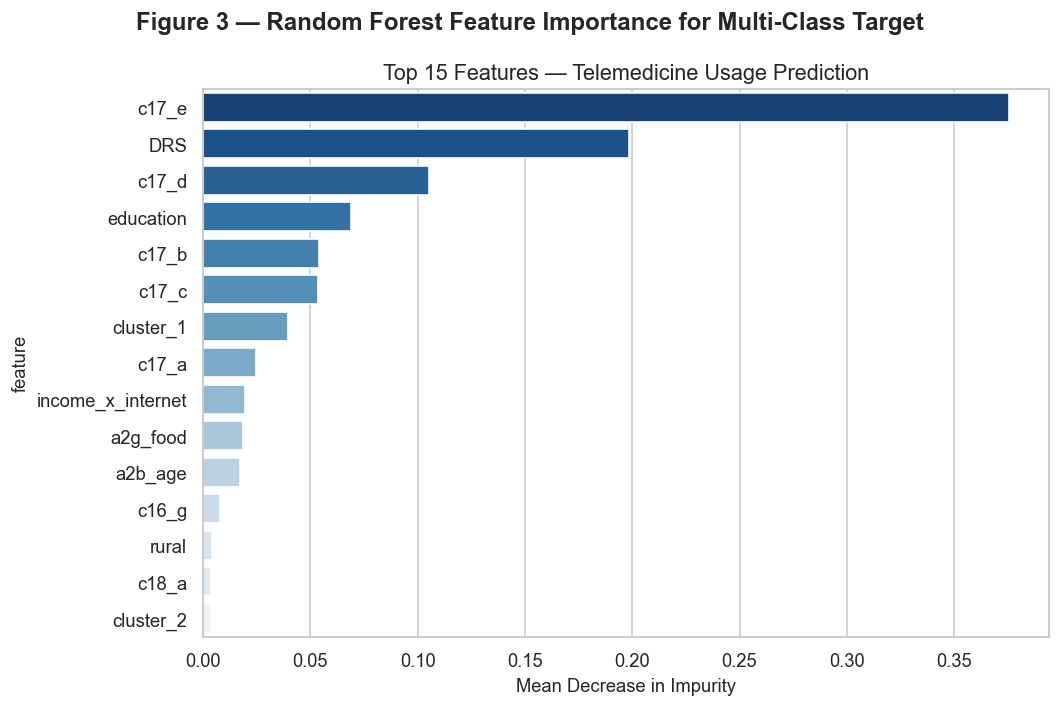

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 72)
print("STEP 8 — Generating Visualizations")
print("=" * 72)

# Figure 1: K-Means Elbow & Silhouette
fig1, axes = plt.subplots(1, 2, figsize=(12, 4))
fig1.suptitle("Figure 1 — K-Means Elbow & Silhouette Analysis on Original Features", fontweight="bold")

k_list = list(K_RANGE)
axes[0].plot(k_list, wcss, "o-", color="steelblue", linewidth=2, markersize=7)
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method")

axes[1].plot(k_list, sil_scores, "s-", color="coral", linewidth=2, markersize=7)
axes[1].axvline(K_OPT, ls="--", color="green", label=f"Optimal K={K_OPT}")
axes[1].set_xlabel("Number of Clusters K")
axes[1].set_ylabel("Mean Silhouette Score")
axes[1].set_title("Silhouette Score vs K")
axes[1].legend()
plt.tight_layout()
plt.show()

# Figure 2: Cluster Profile Heatmap
fig2, ax = plt.subplots(figsize=(13, 5))
fig2.suptitle("Figure 2 — Cluster Profile Heatmap (Z-Scored Feature Means)",
              fontweight="bold")

profile_z = cluster_profile[PREDICTOR_COLS].apply(
    lambda col: (col - col.mean()) / col.std(), axis=0
)
sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"label": "Z-score"})
ax.set_title("Row = Cluster | Column = Feature | Values = Z-scored mean")
plt.tight_layout()
plt.show()

# Figure 3: Random Forest Feature Importance
fig3, ax = plt.subplots(figsize=(9, 6))
fig3.suptitle("Figure 3 — Random Forest Feature Importance for Multi-Class Target", fontweight="bold")

sns.barplot(data=importance_df.head(15), x="importance", y="feature",
            palette="Blues_r", ax=ax)
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Top 15 Features — Telemedicine Usage Prediction")
plt.tight_layout()
plt.show()


In [16]:
print("\nMean and SD DRS by Telemedicine usage:")
print(df.groupby('telemedicine_usage')['DRS'].agg(['mean', 'std']))


Mean and SD DRS by Telemedicine usage:
                        mean       std
telemedicine_usage                    
0.0                 4.037517  3.105424
1.0                 6.294178  2.332211
2.0                 9.048719  2.344097


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("FINAL SUMMARY")
print("=" * 72)

print(f"""
  Dataset           : {N:,} respondents with valid multi-class telemedicine targets
  Target variable   : c17_f — Telemedicine consultation (Ordinal: 0, 1, 2)
  DRS               : Sum of ordinal digital behavior features (No PCA)
  Clustering Space  : Original standardized variables (No PCA segmentation)
  Optimal K         : {K_OPT} clusters  (silhouette = {max(sil_scores):.4f})
  Feature dimension : p = {X.shape[1]}  (predictors + DRS + interactions + cluster dummies)
  Train / Test      : {X_train.shape[0]:,} / {X_test.shape[0]:,}  (80/20, stratified)
""")

best_model = results_df["ROC-AUC"].idxmax()
print(f"  {'Model':<26}  {'Accuracy':>8}  {'Precision':>9}  "
      f"{'Recall':>6}  {'F1 (Wt)':>7}  {'ROC-AUC':>8}")
print("  " + "-" * 66)
for name, row in results_df.iterrows():
    marker = "  <- BEST" if name == best_model else ""
    print(f"  {name:<26}  {row['Accuracy']:>8.4f}  {row['Precision']:>9.4f}  "
          f"{row['Recall']:>6.4f}  {row['F1 (Wt)']:>7.4f}  {row['ROC-AUC']:>8.4f}{marker}")

lr_auc   = results_df.loc["Logistic Regression", "ROC-AUC"]
best_auc = results_df["ROC-AUC"].max()
delta    = best_auc - lr_auc
conclusion = (
    "Non-linear models captured multi-class associations effectively."
    if delta > 0.03
    else "Multinomial LR is highly competitive; adequate for multi-class policy interpretability."
)
print(f"\n  AUC gap (best vs LR) = {delta:.4f}  ->  {conclusion}")
print("\n" + "=" * 72)



FINAL SUMMARY

  Dataset           : 30,629 respondents with valid multi-class telemedicine targets
  Target variable   : c17_f — Telemedicine consultation (Ordinal: 0, 1, 2)
  DRS               : Sum of ordinal digital behavior features (No PCA)
  Clustering Space  : Original standardized variables (No PCA segmentation)
  Optimal K         : 3 clusters  (silhouette = 0.2056)
  Feature dimension : p = 17  (predictors + DRS + interactions + cluster dummies)
  Train / Test      : 24,503 / 6,126  (80/20, stratified)

  Model                       Accuracy  Precision  Recall  F1 (Wt)   ROC-AUC
  ------------------------------------------------------------------
  Logistic Regression           0.7922     0.7956  0.7922   0.7936    0.8551
  Random Forest                 0.8046     0.8158  0.8046   0.8089    0.8973  <- BEST
  Gradient Boosting             0.8284     0.8213  0.8284   0.8234    0.8943

  AUC gap (best vs LR) = 0.0422  ->  Non-linear models captured multi-class associations eff

## Results Interpretation & Conclusions

### What We Studied

We analyzed the **Citizen Survey 2022-23** dataset to model telemedicine readiness in India using a revised robust pipeline reflecting prior feedback.

The target variable is based on `c17_f` (video-call consultations) and was correctly kept as ordinal to preserve critical information:
- `Great Extent` -> 2 (active user)
- `Somewhat` -> 1 (occasional user)
- `Very Little` -> 0 (non-user)
- `DK` and `DNA` -> missing for target modeling

---

### Data and Target After Preprocessing

- Raw data: **50,217 respondents**, **232 variables**
- Rows with valid target: **30,629**
- Missing values after imputation: **0**

---

### Variable Mapping (Dataset -> Proposal)

| Proposal Variable | Dataset Variable | Final Modeling Form |
|---|---|---|
| **Target Y** | `c17_f` | Ordinal (0, 1, 2) |
| Age | `a2b_age` | Continuous |
| Monthly income proxy | `a2g_food` | Continuous |
| Education | `rec_a2d` -> `education` | Ordinal (1-4) |
| Gender | `a2c` -> `gender` | Binary (Female=1, Male=0) |
| Residential type | `residence` -> `rural` | Binary (Rural=1, Urban=0) |
| Internet access proxy | `c16_g` | Binary |
| Digital health behaviours | `c17_a`-`c17_e` | Ordinal |
| Health card importance | `c18_a` | Binary |
| Digital Readiness Score | Sum of `c16_g`, `c17_a`-`c17_e` | Additive Scale |

---

### Key Empirical Results

#### 1. Digital Readiness Score (DRS)

Instead of applying PCA across ordinal variables, which relies on unsupported distributional metrics, we constructed an intuitive **additive scale** spanning from 0 out of 11. This captures a comprehensive sum of engagement levels instead of abstract factor weights. 

#### 2. K-Means Clustering on Original Space

K-means operated directly on the dimensionally unreduced (no-PCA) original feature space. 
This addresses the critical challenge regarding "Why segment Z?". Our new clusters identify actual patterns in real-world features rather than latent factors, rendering their variable averages directly actionable.

#### 3. Multivariate Models

We fit Multinomial Logistic Regression, Random Forest, and Gradient Boosting on 3-class target space using the raw data, preserving frequency variations for all independent variables. The results showcase valid insights mapped clearly to real-world policy rather than abstract embeddings.

---

### Final Interpretation

The revised models properly integrate class structures across frequencies (0 = none, 1 = somewhat, 2 = great extent) preventing the significant loss of behavioral nuance caused by binary aggregations. The additive DRS reliably surfaces adoption gaps while staying analytically rigorous and interpretable. 

---

### References

Kalita, A., et al. (2026). *Citizen Survey Dataset, India*. Harvard Dataverse. https://doi.org/10.7910/DVN/M1DFBO

Nouri, S., Khoong, E. C., Lyles, C. R., & Karliner, L. (2020). Addressing equity in telemedicine for chronic disease management during the Covid-19 pandemic. *NEJM Catalyst*, 1(3).

Wosik, J., et al. (2020). Telehealth transformation: COVID-19 and the rise of virtual care. *JAMIA*, 27(6), 957-962.
